In [ ]:
import os
import sys
import hashlib
import h5py
import numpy as np
import torch
import time
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


THIS_DIR = os.getcwd()
MODULE_DIR = THIS_DIR
TAGGING_DIR = os.path.abspath(os.path.join(MODULE_DIR, '..'))

sys.path.insert(0, MODULE_DIR)

import tool  # noqa: E402
from model import TokenMLP, ParticleTransformerKD  # noqa: E402

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

RUN_NAME = 'unsmear_mlp_vs_hlt_baselines'
OUT_DIR = os.path.join(MODULE_DIR, 'runs', RUN_NAME)
FIG_DIR = os.path.join(OUT_DIR, 'figs')
CKPT_DIR = os.path.join(OUT_DIR, 'ckpts')
SHARED_BASELINE_DIR = os.path.join(MODULE_DIR, 'runs', 'shared_offline_hlt_baselines')
SHARED_BASELINE_CKPT_DIR = os.path.join(SHARED_BASELINE_DIR, 'ckpts')

tool.ensure_dir(FIG_DIR)
tool.ensure_dir(CKPT_DIR)
tool.ensure_dir(SHARED_BASELINE_CKPT_DIR)

CONFIG = {
    'data_path': os.path.join(TAGGING_DIR, 'test.h5'),
    'n_jets': 200000,
    'max_particles': 100,
    'feature_kind': '4d',
    'load_shared_baselines': True,
    'load_unsmear_bundle': False,
    'mlp': {
        'input_dim': 7,
        'hidden_dim': 256,
        'num_layers': 4,
        'dropout': 0.1,
        'return_reco': True,
        'predict_logvar': False,
        'add_mask_channel': False,
        'mask_output': True,
        'w_dr': 0,
    },
    'hlt_effects': {
        'pt_threshold_offline': 0.5,
        'pt_threshold_hlt': 0.5,
        'pt_resolution': 0.10,
        'eta_resolution': 0.03,
        'phi_resolution': 0.03,
    },
    'visual': {
        'n_scatter': 100000,
        'n_bins': 20,
    },
    'tagger': {
        'input_dim': 7,
        'embed_dim': 128,
        'num_heads': 8,
        'num_layers': 6,
        'ff_dim': 512,
        'dropout': 0.1,
    },
    'training': {
        'batch_size': 256,
        'epochs': 50,
        'lr': 5e-4,
        'weight_decay': 1e-5,
        'warmup_epochs': 3,
        'patience': 8,
    },
}

feat_names = tool.get_feat_names(CONFIG['feature_kind'])
CONFIG['mlp']['input_dim'] = len(feat_names)
CONFIG['tagger']['input_dim'] = len(feat_names)

print('Data path:', CONFIG['data_path'])
print('Run dir:', OUT_DIR)
print('Feature kind:', CONFIG['feature_kind'], 'feat_names:', feat_names)

Device: cuda
Data path: d:\PracticeTagging\tagging\test.h5
Run dir: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines
Feature kind: 7d feat_names: ['dEta', 'dPhi', 'log_pt', 'log_E', 'log_pt_rel', 'log_E_rel', 'dR']


In [2]:
# Load raw constituents
n = int(CONFIG['n_jets'])
S = int(CONFIG['max_particles'])

with h5py.File(CONFIG['data_path'], 'r') as f:
    labels = f['labels'][:n].astype(np.int64)
    weights = f['weights'][:n].astype(np.float32)
    pt = f['fjet_clus_pt'][:n, :S].astype(np.float32)
    eta = f['fjet_clus_eta'][:n, :S].astype(np.float32)
    phi = f['fjet_clus_phi'][:n, :S].astype(np.float32)
    E = f['fjet_clus_E'][:n, :S].astype(np.float32)

constituents_raw = np.stack([pt, eta, phi, E], axis=-1)
mask_raw = pt > 0

print('Raw:', constituents_raw.shape, 'mask:', mask_raw.shape)
print('Signal:', int(labels.sum()), 'Bkg:', int((1 - labels).sum()))

Raw: (200000, 100, 4) mask: (200000, 100)
Signal: 99836 Bkg: 100164


In [3]:
# Build offline and smeared-HLT views
hcfg = tool.HLTEffectsCfg(**CONFIG['hlt_effects'])

_, hlt_const, hlt_mask = tool.apply_hlt_effects_pair(
    constituents_raw,
    mask_raw,
    hcfg,
    seed=seed,
)

pt_thr_off = float(CONFIG['hlt_effects']['pt_threshold_offline'])
off_mask = mask_raw & (constituents_raw[:, :, 0] >= pt_thr_off)
off_const = constituents_raw.copy()
off_const[~off_mask] = 0.0
hlt_const = hlt_const.copy()
hlt_const[~hlt_mask] = 0.0

print('Offline/HLT:', off_const.shape, hlt_const.shape)
print('Avg tokens per jet | offline:', float(off_mask.sum(axis=1).mean()))
print('Avg tokens per jet | hlt    :', float(hlt_mask.sum(axis=1).mean()))
print('Mask identical:', bool(np.array_equal(off_mask, hlt_mask)))

axis_off = tool.compute_jet_axis(off_const, off_mask)
axis_hlt = tool.compute_jet_axis(hlt_const, hlt_mask)
feat_off = tool.compute_features_with_axis(off_const, off_mask, axis_off, kind=CONFIG['feature_kind'])
feat_hlt = tool.compute_features_with_axis(hlt_const, hlt_mask, axis_hlt, kind=CONFIG['feature_kind'])

print('Features:', feat_off.shape, feat_hlt.shape, 'kind:', CONFIG['feature_kind'])

idx = np.arange(len(labels))
train_idx, temp_idx = train_test_split(idx, test_size=0.30, random_state=seed, stratify=labels)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=seed, stratify=labels[temp_idx])
print(f'Split: train={len(train_idx):,} val={len(val_idx):,} test={len(test_idx):,}')

Offline/HLT: (200000, 100, 4) (200000, 100, 4)
Avg tokens per jet | offline: 54.29243
Avg tokens per jet | hlt    : 54.29243
Mask identical: True
Features: (200000, 100, 7) (200000, 100, 7) kind: 7d
Split: train=140,000 val=30,000 test=30,000


In [9]:
print(train_idx[:10])

[109063 116698  27705   1877  24458  63824  22373 178411 187204 147008]


In [4]:
# Standardize using offline train statistics
feat_means, feat_stds = tool.get_stats(feat_off, off_mask, train_idx)

feat_off_std = tool.standardize(feat_off, off_mask, feat_means, feat_stds, clip=10.0)
feat_hlt_std = tool.standardize(feat_hlt, hlt_mask, feat_means, feat_stds, clip=10.0)
common_mask = off_mask & hlt_mask

print('Standardization done.')
print('Means:', np.round(feat_means, 4))
print('Stds :', np.round(feat_stds, 4))
print('Common-mask fraction:', float(common_mask.mean()))

Standardization done.
Means: [-2.0000e-04 -1.0000e-04  8.7940e+00  9.0840e+00 -5.2585e+00 -5.2701e+00
  2.2250e-01]
Stds : [0.2121 0.2173 1.5182 1.5217 1.4919 1.4935 0.2067]
Common-mask fraction: 0.5429243


In [5]:
# DataLoaders for MLP unsmear training
BS_UNSMEAR = int(CONFIG['training']['batch_size'])

train_uns_ds = tool.UnsmearJetDataset(feat_hlt_std[train_idx], feat_off_std[train_idx], common_mask[train_idx])
val_uns_ds = tool.UnsmearJetDataset(feat_hlt_std[val_idx], feat_off_std[val_idx], common_mask[val_idx])
test_uns_ds = tool.UnsmearJetDataset(feat_hlt_std[test_idx], feat_off_std[test_idx], common_mask[test_idx])

train_uns_loader = DataLoader(train_uns_ds, batch_size=BS_UNSMEAR, shuffle=True, drop_last=True)
val_uns_loader = DataLoader(val_uns_ds, batch_size=BS_UNSMEAR)
test_uns_loader = DataLoader(test_uns_ds, batch_size=BS_UNSMEAR)

x_std = feat_hlt_std[test_idx]
y_std = feat_off_std[test_idx]
mask_np = common_mask[test_idx]

print('Unsmear loaders ready, BS=', BS_UNSMEAR)
print('Test tensors:', x_std.shape, y_std.shape, mask_np.shape)
print('Valid tokens in test split:', int(mask_np.sum()))

Unsmear loaders ready, BS= 256
Test tensors: (30000, 100, 7) (30000, 100, 7) (30000, 100)
Valid tokens in test split: 1630900


[MLP] ep=001 train=0.493567 val=0.041327 best=0.041327 no_imp=0 time=33.8s
[MLP] ep=005 train=0.042606 val=0.040684 best=0.040684 no_imp=0 time=137.8s
[MLP] ep=010 train=0.040515 val=0.040165 best=0.040165 no_imp=0 time=320.1s
[MLP] ep=015 train=0.040187 val=0.040109 best=0.040109 no_imp=0 time=493.7s
[MLP] ep=020 train=0.040021 val=0.039987 best=0.039987 no_imp=0 time=664.3s
[MLP] ep=025 train=0.039899 val=0.039881 best=0.039890 no_imp=1 time=835.5s
[MLP] ep=030 train=0.039808 val=0.039783 best=0.039783 no_imp=0 time=1006.9s
[MLP] ep=035 train=0.039747 val=0.039734 best=0.039734 no_imp=0 time=1179.1s
[MLP] ep=040 train=0.039706 val=0.039670 best=0.039670 no_imp=0 time=1351.4s
[MLP] ep=045 train=0.039682 val=0.039656 best=0.039653 no_imp=1 time=1523.0s
[MLP] ep=050 train=0.039674 val=0.039646 best=0.039653 no_imp=6 time=1694.6s
Saved checkpoint: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\ckpts\unsmear_mlp.pt
MLP test loss: 0.039528596393267314
Saved figur

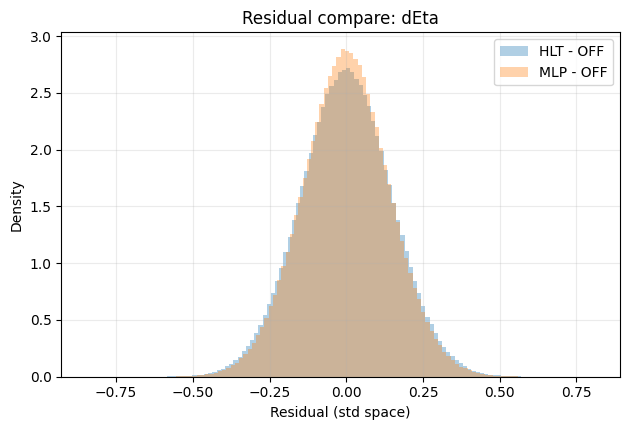

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\figs\mlp_resid_smeared_hlt_vs_offline_dPhi.png


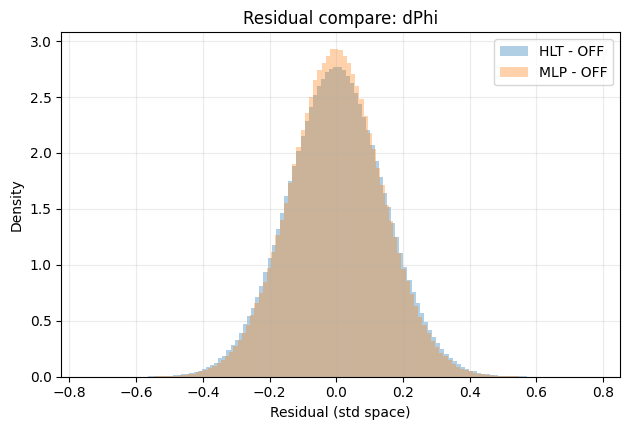

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\figs\mlp_resid_smeared_hlt_vs_offline_log_pt.png


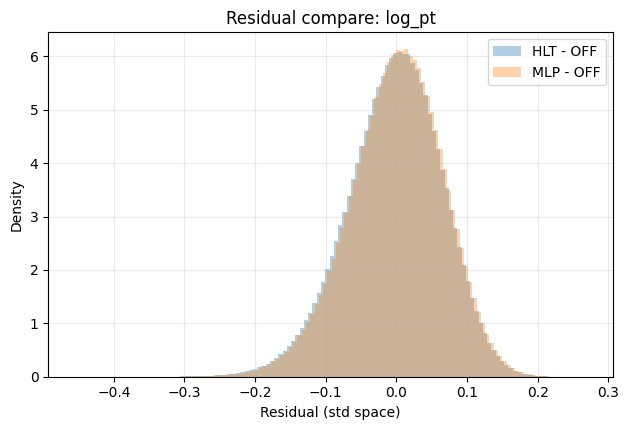

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\figs\mlp_resid_smeared_hlt_vs_offline_log_E.png


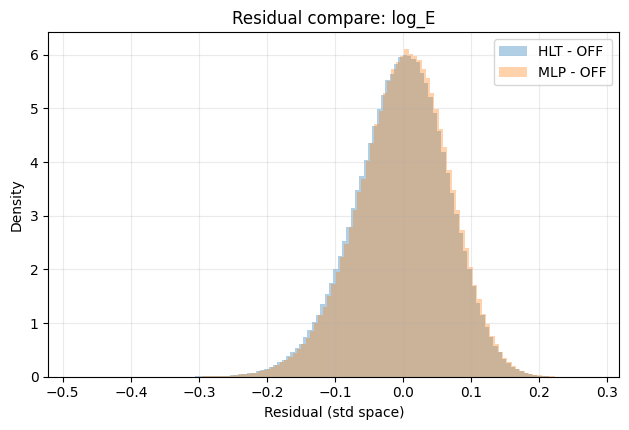

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\figs\mlp_resid_smeared_hlt_vs_offline_log_pt_rel.png


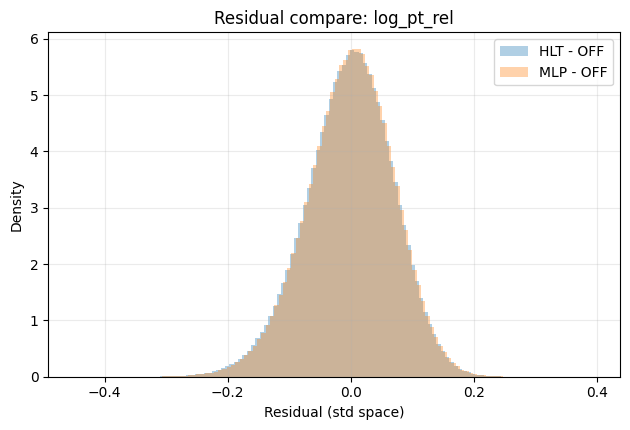

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\figs\mlp_resid_smeared_hlt_vs_offline_log_E_rel.png


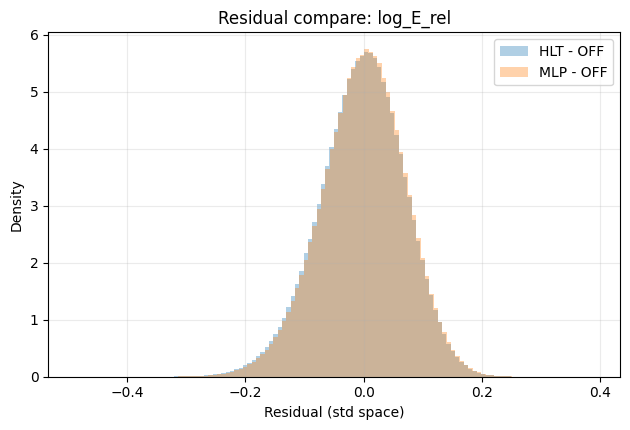

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\figs\mlp_resid_smeared_hlt_vs_offline_dR.png


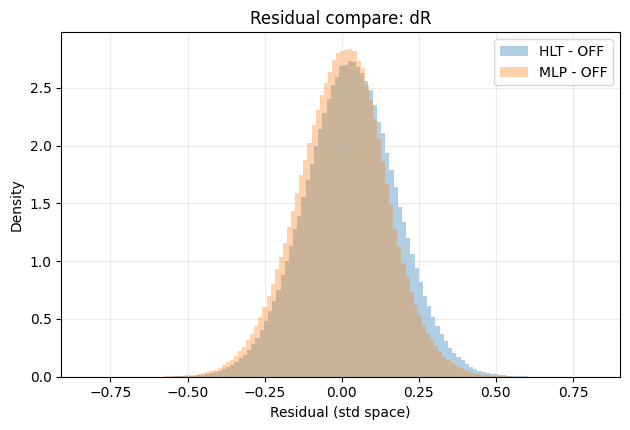

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\figs\mlp_scatter_compare_dEta.png


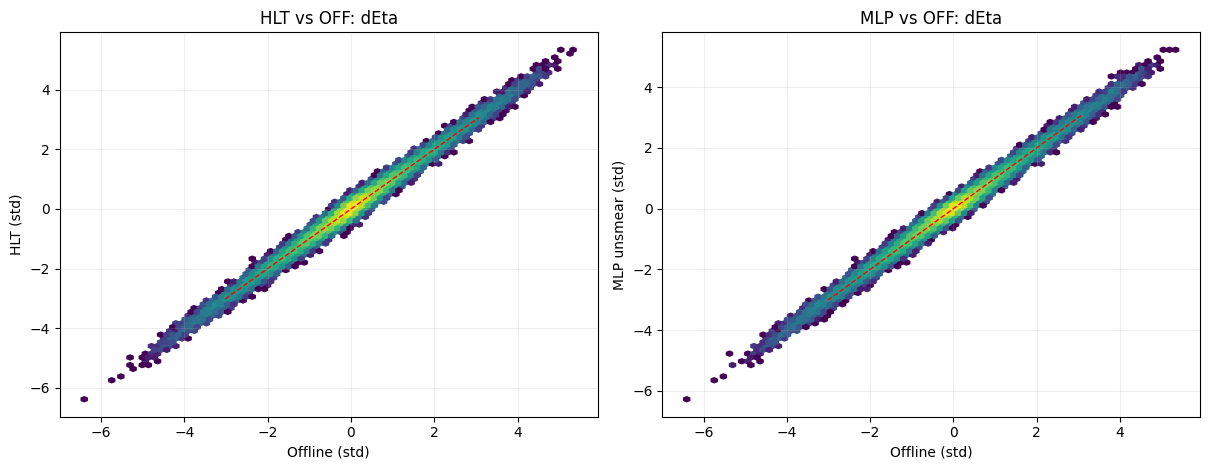

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\figs\mlp_scatter_compare_dPhi.png


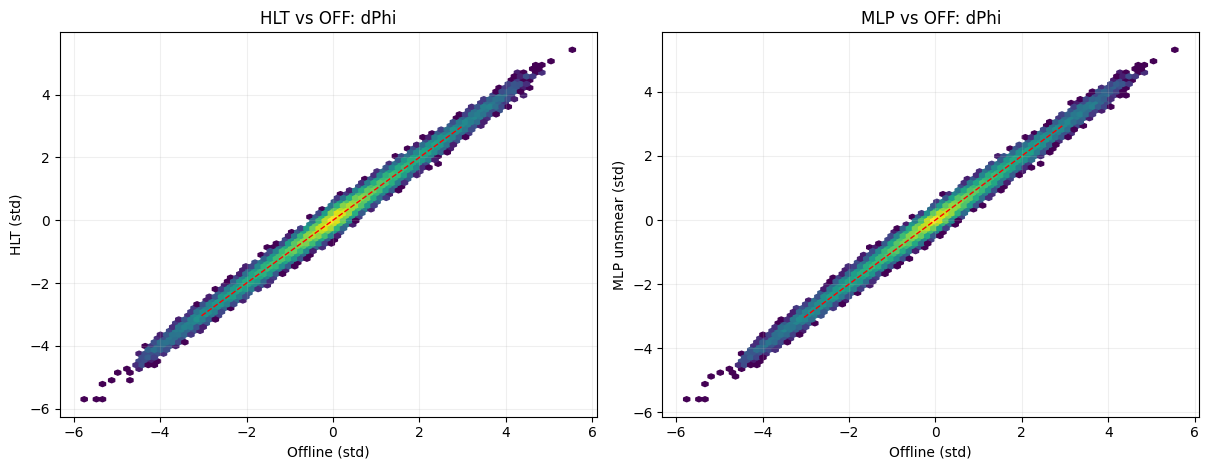

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\figs\mlp_scatter_compare_log_pt.png


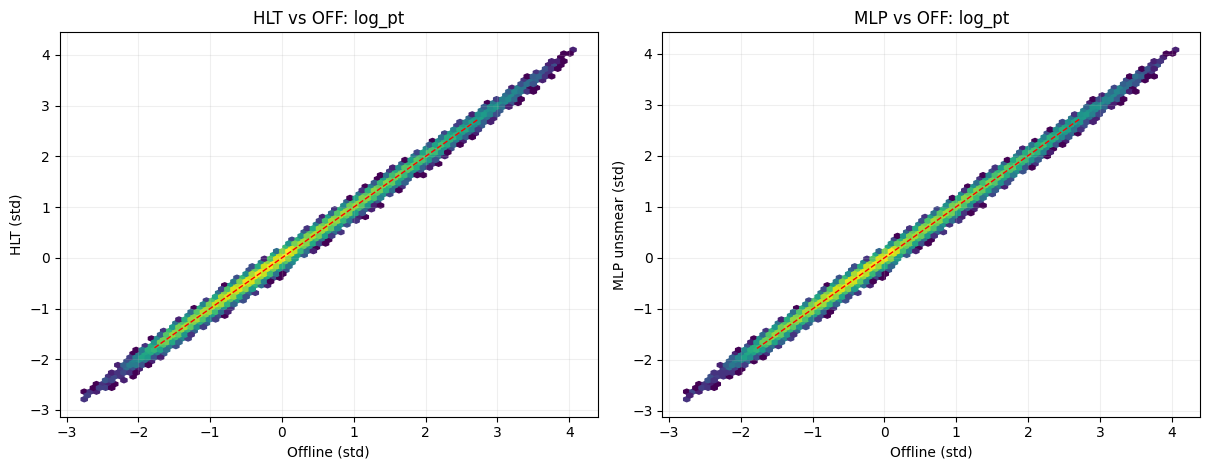

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\figs\mlp_scatter_compare_log_E.png


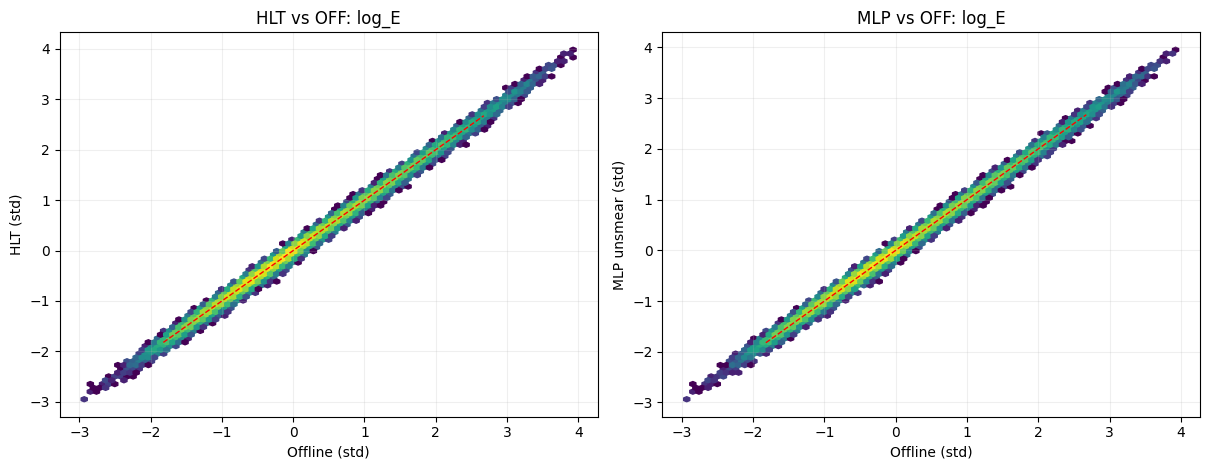

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\figs\mlp_scatter_compare_log_pt_rel.png


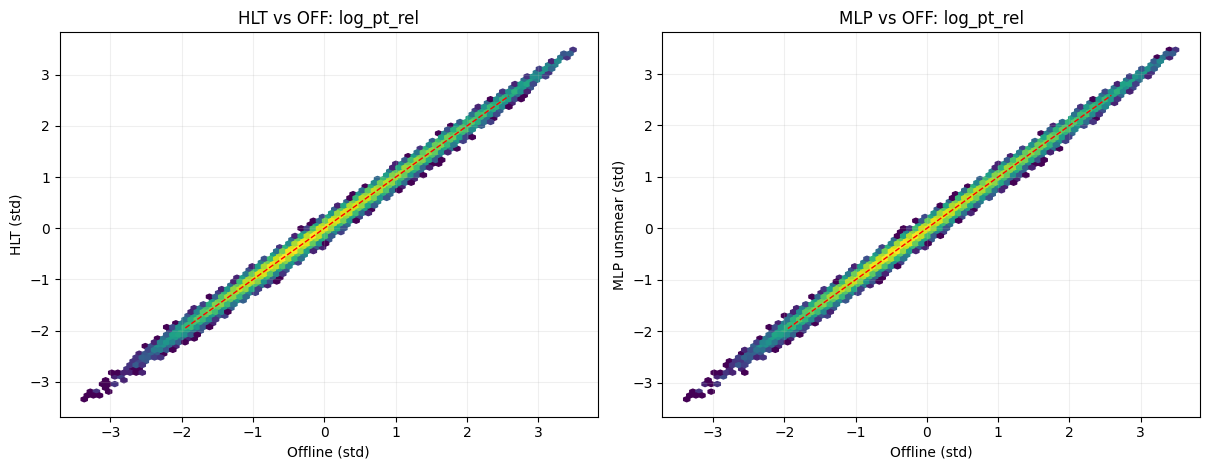

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\figs\mlp_scatter_compare_log_E_rel.png


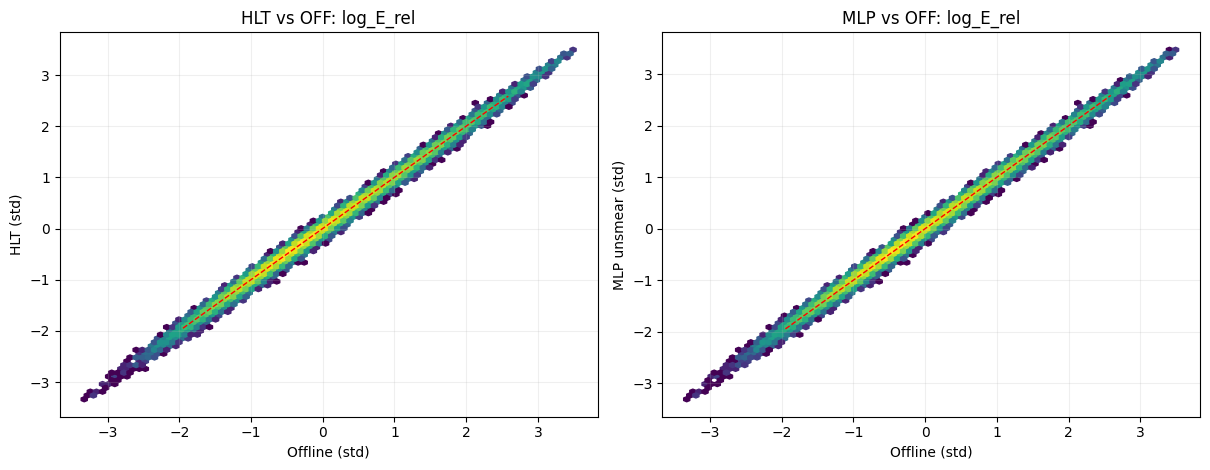

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\figs\mlp_scatter_compare_dR.png


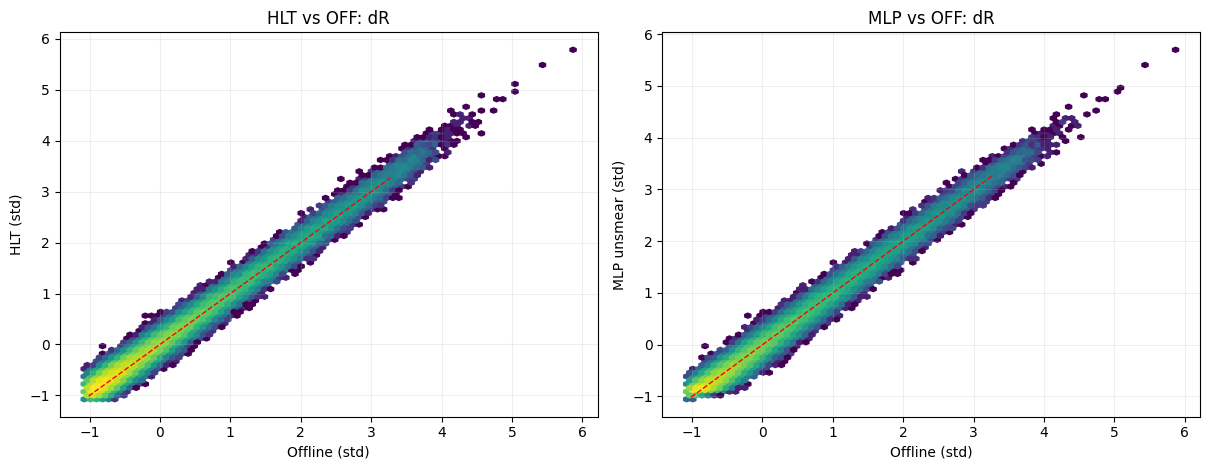


Metrics summary (std space) | n_tokens=1630900
feature	method	bias	mae	rmse	abs_p50	abs_p90	abs_p99
dEta	hlt	-0.000556	0.118285	0.148658	0.099482	0.244542	0.385490
dEta	mlp	-0.000336	0.112740	0.142237	0.094194	0.234315	0.372947
dPhi	hlt	-0.000172	0.115474	0.145006	0.097246	0.238573	0.375467
dPhi	mlp	-0.000656	0.110238	0.138927	0.092256	0.228940	0.363187
log_pt	hlt	-0.003360	0.052877	0.066770	0.044331	0.108811	0.177613
log_pt	mlp	-0.000031	0.052569	0.066257	0.044223	0.108104	0.174822
log_E	hlt	-0.003796	0.053589	0.067663	0.044937	0.110348	0.179946
log_E	mlp	-0.000106	0.053178	0.067009	0.044716	0.109401	0.176582
log_pt_rel	hlt	-0.002749	0.056079	0.070901	0.046882	0.115897	0.188754
log_pt_rel	mlp	-0.000784	0.055715	0.070379	0.046634	0.115129	0.186525
log_E_rel	hlt	-0.003435	0.056860	0.071879	0.047528	0.117525	0.191154
log_E_rel	mlp	-0.001077	0.056388	0.071205	0.047202	0.116484	0.188472
dR	hlt	0.028985	0.120490	0.151625	0.101127	0.249538	0.394740
dR	mlp	0.000167	0.113690	0.143596	0.094925

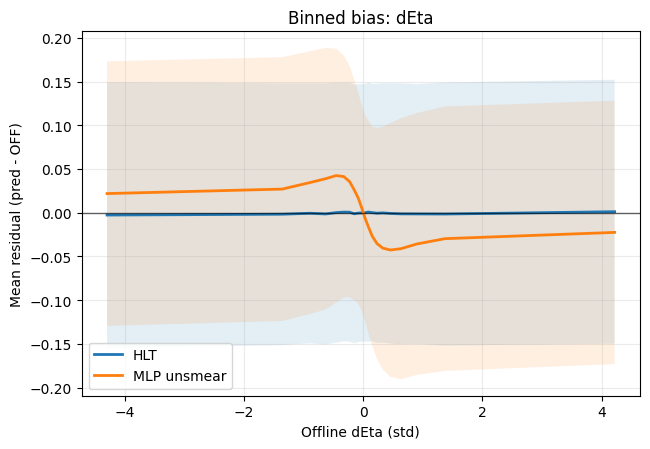

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\figs\mlp_bias_compare_dPhi.png


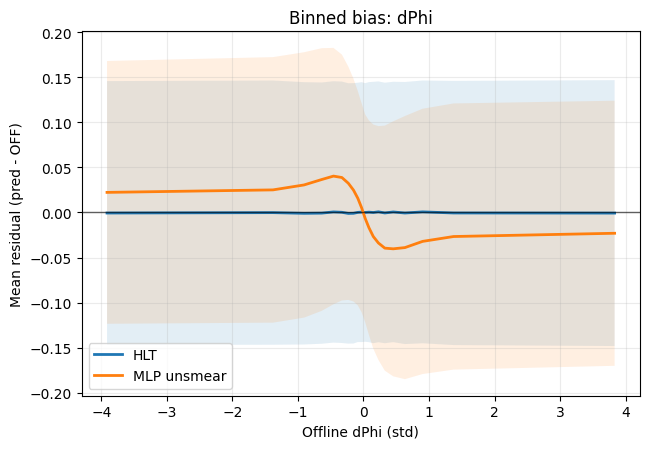

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\figs\mlp_bias_compare_log_pt.png


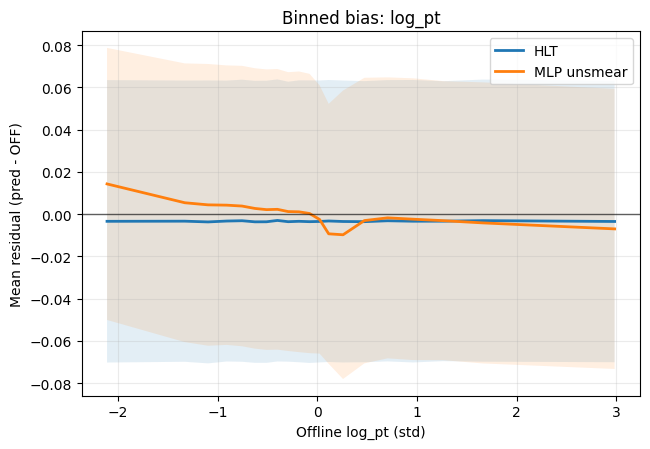

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\figs\mlp_bias_compare_log_E.png


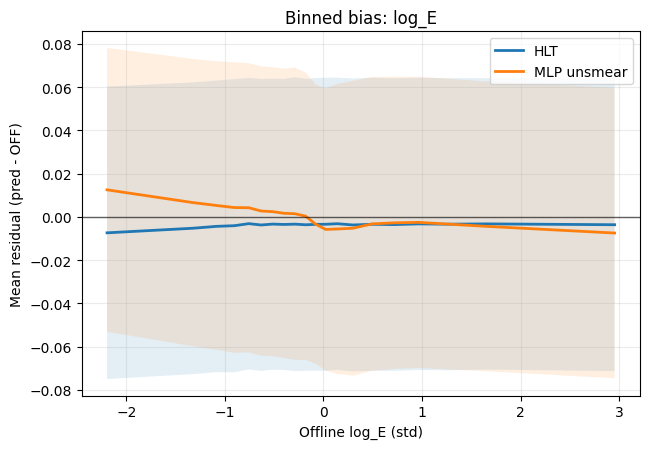

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\figs\mlp_bias_compare_log_pt_rel.png


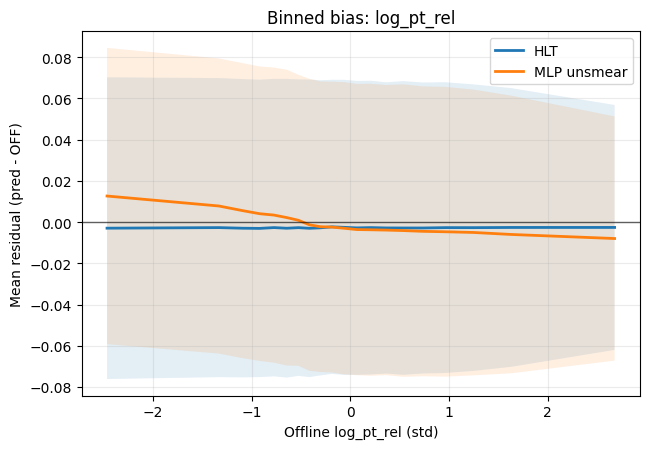

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\figs\mlp_bias_compare_log_E_rel.png


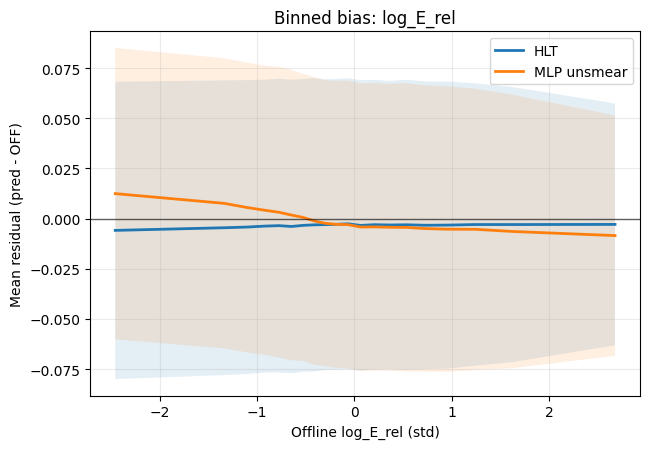

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\runs\unsmear_mlp_vs_hlt_baselines\figs\mlp_bias_compare_dR.png


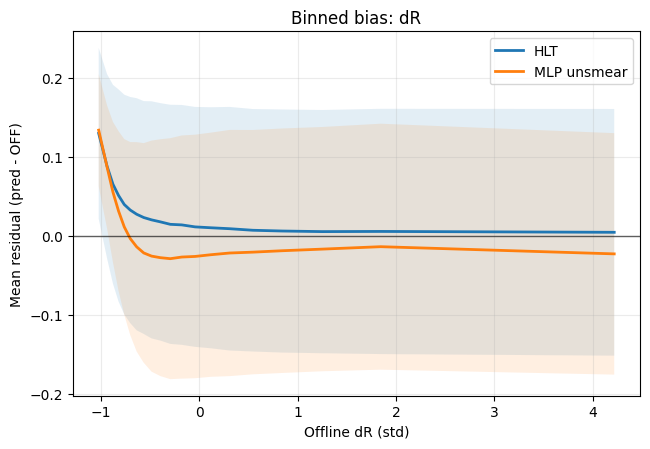

In [ ]:
# Train MLP unsmear model and compare before vs MLP
train_cfg = CONFIG['training']
epochs = int(train_cfg['epochs'])
lr = float(train_cfg['lr'])
wd = float(train_cfg['weight_decay'])
warm = int(train_cfg['warmup_epochs'])
pat = int(train_cfg['patience'])
N_scatter = int(CONFIG['visual']['n_scatter'])
N_BINS = int(CONFIG['visual']['n_bins'])


def make_scheduler(opt):
    def lr_lambda(ep):
        if ep < warm:
            return float(ep + 1) / float(max(1, warm))
        t = (ep - warm) / float(max(1, epochs - warm))
        return 0.5 * (1.0 + np.cos(np.pi * t))

    return torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)


idx_map = {n: i for i, n in enumerate(feat_names)}
dphi_idx = idx_map.get('dPhi', None)
deta_idx = idx_map.get('dEta', None)
dr_idx = idx_map.get('dR', None)
dphi_scale = float(feat_stds[int(dphi_idx)]) if dphi_idx is not None else 1.0
w_dr = CONFIG['mlp']['w_dr']


def regression_loss_terms(mu: torch.Tensor, y: torch.Tensor, m: torch.Tensor) -> dict[str, torch.Tensor]:
    # Base regression term: use a wrap-aware residual for dPhi.
    if dphi_idx is not None:
        base = tool.masked_smooth_l1_wrap_dphi(mu, y, m, dphi_idx=int(dphi_idx), dphi_scale=dphi_scale)
    else:
        base = tool.masked_smooth_l1(mu, y, m)

    cons_raw = torch.zeros((), device=mu.device, dtype=mu.dtype)
    cons_weighted = torch.zeros((), device=mu.device, dtype=mu.dtype)

    # dR consistency term: constrain the predicted dR to match sqrt(dEta^2 + dPhi^2).
    if (w_dr > 0.0) and (dr_idx is not None) and (deta_idx is not None) and (dphi_idx is not None):
        dR_cons = torch.sqrt(mu[..., int(deta_idx)] ** 2 + mu[..., int(dphi_idx)] ** 2 + 1e-12)
        dR_pred = mu[..., int(dr_idx)]
        cons_raw = tool.masked_smooth_l1(dR_pred.unsqueeze(-1), dR_cons.unsqueeze(-1), m)
        cons_weighted = float(w_dr) * cons_raw

    total = base + cons_weighted
    return {
        'total': total,
        'base': base,
        'dr_cons_raw': cons_raw,
        'dr_cons_weighted': cons_weighted,
    }


def regression_loss(mu: torch.Tensor, y: torch.Tensor, m: torch.Tensor) -> torch.Tensor:
    return regression_loss_terms(mu, y, m)['total']


@torch.no_grad()
def eval_regression(model, loader):
    model.eval()
    sums = {'total': 0.0, 'base': 0.0, 'dr_cons_raw': 0.0, 'dr_cons_weighted': 0.0}
    n = 0
    for batch in loader:
        x = batch['x'].to(device)
        y = batch['y'].to(device)
        m = batch['mask'].to(device)
        pred = model(x, m)
        terms = regression_loss_terms(pred, y, m)
        bs = int(x.shape[0])
        for key in sums:
            sums[key] += float(terms[key].item()) * bs
        n += bs
    return {key: val / max(1, n) for key, val in sums.items()}


def train_mlp():
    model = TokenMLP(**CONFIG['mlp']).to(device)
    ckpt_path = os.path.join(CKPT_DIR, 'unsmear_mlp.pt')
    if bool(CONFIG.get('load_unsmear_bundle', False)) and os.path.isfile(ckpt_path):
        obj = torch.load(ckpt_path, map_location='cpu')
        state = obj['state_dict'] if isinstance(obj, dict) and 'state_dict' in obj else obj
        model.load_state_dict(state)
        print('Loaded checkpoint:', ckpt_path)
        return model

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sch = make_scheduler(opt)
    best_val, best_state, no_imp = 0.0, None, 0
    t0 = time.time()
    for ep in range(1, epochs + 1):
        model.train()
        train_sums = {'total': 0.0, 'base': 0.0, 'dr_cons_raw': 0.0, 'dr_cons_weighted': 0.0}
        n = 0
        for batch in train_uns_loader:
            x = batch['x'].to(device)
            y = batch['y'].to(device)
            m = batch['mask'].to(device)
            opt.zero_grad(set_to_none=True)
            pred = model(x, m)
            terms = regression_loss_terms(pred, y, m)
            loss = terms['total']
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            bs = int(x.shape[0])
            for key in train_sums:
                train_sums[key] += float(terms[key].item()) * bs
            n += bs
        train_terms = {key: val / max(1, n) for key, val in train_sums.items()}
        val_terms = eval_regression(model, val_uns_loader)
        val_loss = val_terms['total']
        sch.step()
        if val_loss < best_val - 1e-5 or best_state is None:
            best_val = float(val_loss)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if ep == 1 or ep % 5 == 0:
            dt = time.time() - t0
            print(
                f'[MLP] ep={ep:03d} '
                f'train_total={train_terms["total"]:.6f} '
                f'train_base={train_terms["base"]:.6f} '
                f'train_dr_raw={train_terms["dr_cons_raw"]:.6f} '
                f'train_dr_w={train_terms["dr_cons_weighted"]:.6f} '
                f'val_total={val_terms["total"]:.6f} '
                f'val_base={val_terms["base"]:.6f} '
                f'val_dr_raw={val_terms["dr_cons_raw"]:.6f} '
                f'val_dr_w={val_terms["dr_cons_weighted"]:.6f} '
                f'best={best_val:.6f} no_imp={no_imp} time={dt:.1f}s'
            )
        if no_imp >= pat:
            print('[MLP] Early stopping')
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    torch.save({'state_dict': model.state_dict(), 'best_val': best_val, 'config': CONFIG}, ckpt_path)
    print('Saved checkpoint:', ckpt_path)
    test_terms = eval_regression(model, test_uns_loader)
    print(
        f'MLP test_total={test_terms["total"]:.6f} '
        f'test_base={test_terms["base"]:.6f} '
        f'test_dr_raw={test_terms["dr_cons_raw"]:.6f} '
        f'test_dr_w={test_terms["dr_cons_weighted"]:.6f}'
    )
    return model


@torch.no_grad()
def predict_mlp(model, loader):
    model.eval()
    outs = []
    for batch in loader:
        x = batch['x'].to(device)
        m = batch['mask'].to(device)
        outs.append(model(x, m).cpu().numpy())
    return np.concatenate(outs, axis=0)


mlp = train_mlp()
pred_mlp = predict_mlp(mlp, test_uns_loader)

for i, name in enumerate(feat_names):
    x_i = x_std[..., i][mask_np]
    y_i = y_std[..., i][mask_np]
    m_i = pred_mlp[..., i][mask_np]

    r_hlt = x_i - y_i
    r_mlp = m_i - y_i
    if name == 'dPhi':
        sc = float(feat_stds[i])
        r_hlt = tool.wrap_dphi_np(r_hlt * sc) / sc
        r_mlp = tool.wrap_dphi_np(r_mlp * sc) / sc

    plt.figure(figsize=(6.4, 4.4))
    plt.hist(r_hlt, bins=120, density=True, alpha=0.35, label='HLT - OFF')
    plt.hist(r_mlp, bins=120, density=True, alpha=0.35, label='MLP - OFF')
    plt.title(f'Residual compare: {name}')
    plt.xlabel('Residual (std space)')
    plt.ylabel('Density')
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    out = os.path.join(FIG_DIR, f'mlp_resid_smeared_hlt_vs_offline_{name}.png')
    plt.savefig(out, dpi=160, bbox_inches='tight')
    print('Saved figure:', out)
    plt.show()

sel = np.where(mask_np.reshape(-1))[0]
if sel.size > N_scatter:
    sel = np.random.RandomState(0).choice(sel, size=N_scatter, replace=False)

for i, name in enumerate(feat_names):
    y_flat = y_std[..., i].reshape(-1)[sel]
    x_flat = x_std[..., i].reshape(-1)[sel]
    m_flat = pred_mlp[..., i].reshape(-1)[sel]
    lo = np.percentile(np.concatenate([y_flat, x_flat, m_flat]), 1)
    hi = np.percentile(np.concatenate([y_flat, x_flat, m_flat]), 99)

    plt.figure(figsize=(12.2, 4.8))
    plt.subplot(1, 2, 1)
    plt.hexbin(y_flat, x_flat, gridsize=80, bins='log', mincnt=1)
    plt.plot([lo, hi], [lo, hi], 'r--', lw=1)
    plt.xlabel('Offline (std)')
    plt.ylabel('HLT (std)')
    plt.title(f'HLT vs OFF: {name}')
    plt.grid(True, alpha=0.2)

    plt.subplot(1, 2, 2)
    plt.hexbin(y_flat, m_flat, gridsize=80, bins='log', mincnt=1)
    plt.plot([lo, hi], [lo, hi], 'r--', lw=1)
    plt.xlabel('Offline (std)')
    plt.ylabel('MLP unsmear (std)')
    plt.title(f'MLP vs OFF: {name}')
    plt.grid(True, alpha=0.2)

    plt.tight_layout()
    out = os.path.join(FIG_DIR, f'mlp_scatter_compare_{name}.png')
    plt.savefig(out, dpi=160, bbox_inches='tight')
    print('Saved figure:', out)
    plt.show()


def _metrics(res_1d: np.ndarray):
    if res_1d.size == 0:
        return {'bias': np.nan, 'mae': np.nan, 'rmse': np.nan, 'p50': np.nan, 'p90': np.nan, 'p99': np.nan}
    abs_r = np.abs(res_1d)
    return {
        'bias': float(np.mean(res_1d)),
        'mae': float(np.mean(abs_r)),
        'rmse': float(np.sqrt(np.mean(res_1d ** 2))),
        'p50': float(np.quantile(abs_r, 0.50)),
        'p90': float(np.quantile(abs_r, 0.90)),
        'p99': float(np.quantile(abs_r, 0.99)),
    }

print()
print('=' * 90)
print(f'Metrics summary (std space) | n_tokens={int(mask_np.sum())}')
print('=' * 90)
print('	'.join(['feature', 'method', 'bias', 'mae', 'rmse', 'abs_p50', 'abs_p90', 'abs_p99']))
for i, name in enumerate(feat_names):
    for method, arr in [('hlt', x_std - y_std), ('mlp', pred_mlp - y_std)]:
        r = arr[..., i][mask_np]
        if name == 'dPhi':
            sc = float(feat_stds[i])
            r = tool.wrap_dphi_np(r * sc) / sc
        mm = _metrics(r)
        print('	'.join([
            name,
            method,
            f"{mm['bias']:.6f}",
            f"{mm['mae']:.6f}",
            f"{mm['rmse']:.6f}",
            f"{mm['p50']:.6f}",
            f"{mm['p90']:.6f}",
            f"{mm['p99']:.6f}",
        ]))

for i, name in enumerate(feat_names):
    y_flat = y_std[..., i][mask_np]
    hlt_flat = (x_std[..., i] - y_std[..., i])[mask_np]
    mlp_flat = (pred_mlp[..., i] - y_std[..., i])[mask_np]
    if name == 'dPhi':
        sc = float(feat_stds[i])
        hlt_flat = tool.wrap_dphi_np(hlt_flat * sc) / sc
        mlp_flat = tool.wrap_dphi_np(mlp_flat * sc) / sc
    if y_flat.size < 1000:
        continue
    edges = np.unique(np.quantile(y_flat, np.linspace(0.0, 1.0, N_BINS + 1)))
    if edges.size < 3:
        continue
    centers = 0.5 * (edges[:-1] + edges[1:])

    def _bin_stats(r_flat):
        means, stds = [], []
        for lo, hi in zip(edges[:-1], edges[1:]):
            inb = (y_flat >= lo) & (y_flat < hi)
            if not np.any(inb):
                means.append(np.nan)
                stds.append(np.nan)
            else:
                means.append(float(np.mean(r_flat[inb])))
                stds.append(float(np.std(r_flat[inb])))
        return np.asarray(means), np.asarray(stds)

    mh, sh = _bin_stats(hlt_flat)
    mm, sm = _bin_stats(mlp_flat)

    plt.figure(figsize=(6.6, 4.6))
    plt.plot(centers, mh, lw=2, label='HLT')
    plt.fill_between(centers, mh - sh, mh + sh, alpha=0.12)
    plt.plot(centers, mm, lw=2, label='MLP unsmear')
    plt.fill_between(centers, mm - sm, mm + sm, alpha=0.12)
    plt.axhline(0.0, color='k', lw=1, alpha=0.6)
    plt.xlabel(f'Offline {name} (std)')
    plt.ylabel('Mean residual (pred - OFF)')
    plt.title(f'Binned bias: {name}')
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    out = os.path.join(FIG_DIR, f'mlp_bias_compare_{name}.png')
    plt.savefig(out, dpi=160, bbox_inches='tight')
    print('Saved figure:', out)
    plt.show()


In [ ]:
# Downstream tagger training setup: teacher / HLT baseline / MLP-unsmear
mlp_train_std = np.zeros_like(feat_hlt_std[train_idx])
mlp_val_std = np.zeros_like(feat_hlt_std[val_idx])
mlp_test_std = np.zeros_like(feat_hlt_std[test_idx])

@torch.no_grad()
def _predict_mlp_np(model, x_np: np.ndarray, mask_np_local: np.ndarray, *, bs: int = 512) -> np.ndarray:
    model.eval()
    ds = tool.UnsmearJetDataset(x_np, x_np, mask_np_local)
    ld = DataLoader(ds, batch_size=int(bs), shuffle=False)
    outs = []
    for batch in ld:
        x = batch['x'].to(device)
        m = batch['mask'].to(device)
        outs.append(model(x, m).cpu().numpy())
    return np.concatenate(outs, axis=0)


def _slice_axis(axis: dict, idx: np.ndarray) -> dict:
    return {k: np.asarray(v)[idx] for k, v in axis.items()}


def _rebuild_pred_for_downstream(pred_std: np.ndarray, mask_np_local: np.ndarray, axis_local: dict) -> np.ndarray:
    # Before downstream evaluation, forcibly rebuild the last 3 dimensions from the first 4 so the relative quantities and dR stay physically consistent with the first 4 dimensions.
    pred_std = np.asarray(pred_std, dtype=np.float32)
    mask_np_local = np.asarray(mask_np_local, dtype=bool)

    pred_raw4 = pred_std[..., :4] * feat_stds[:4] + feat_means[:4]
    pred_raw4 = np.asarray(pred_raw4, dtype=np.float32)
    pred_raw4[..., 1] = tool.wrap_dphi_np(pred_raw4[..., 1])
    pred_raw4[~mask_np_local] = 0.0

    pred_raw7 = tool.feats_to_7d(pred_raw4, mask_np_local, axis_local, kind='4d')
    pred_std7 = tool.standardize(pred_raw7, mask_np_local, feat_means, feat_stds, clip=10.0)
    pred_std7[~mask_np_local] = 0.0
    return pred_std7.astype(np.float32)


mlp_train_pred_std = _predict_mlp_np(mlp, feat_hlt_std[train_idx], common_mask[train_idx])
mlp_val_pred_std = _predict_mlp_np(mlp, feat_hlt_std[val_idx], common_mask[val_idx])
mlp_test_pred_std = _predict_mlp_np(mlp, feat_hlt_std[test_idx], common_mask[test_idx])

mlp_train_std = _rebuild_pred_for_downstream(mlp_train_pred_std, common_mask[train_idx], _slice_axis(axis_off, train_idx))
mlp_val_std = _rebuild_pred_for_downstream(mlp_val_pred_std, common_mask[val_idx], _slice_axis(axis_off, val_idx))
mlp_test_std = _rebuild_pred_for_downstream(mlp_test_pred_std, common_mask[test_idx], _slice_axis(axis_off, test_idx))

try:
    m_tr = common_mask[train_idx]
    mae_hlt = float(np.mean(np.abs((feat_hlt_std[train_idx] - feat_off_std[train_idx])[m_tr])))
    mae_mlp = float(np.mean(np.abs((mlp_train_std - feat_off_std[train_idx])[m_tr])))
    print('Sanity MAE vs OFF (train, std): HLT=', mae_hlt, 'MLP downstream-ready=', mae_mlp)
except Exception as e:
    print('Sanity MAE vs OFF skipped:', repr(e))

        # Compare the last 3 dimensions: direct predictions vs values rebuilt from the first 4 dimensions in the off-axis frame.
        post3_names = ['log_pt_rel', 'log_E_rel', 'dR']
post3_idx = [idx_map[n] for n in post3_names if n in idx_map]
post3_mask = common_mask[test_idx]

print()
print('=' * 90)
print(f'Post-3D compare vs OFF (std space) | n_tokens={int(post3_mask.sum())}')
print('=' * 90)
print('\t'.join(['feature', 'method', 'bias', 'mae', 'rmse', 'abs_p50', 'abs_p90', 'abs_p99']))
for i in post3_idx:
    name = feat_names[i]
    y_i = feat_off_std[test_idx][..., i]
    direct_i = mlp_test_pred_std[..., i]
    rebuilt_i = mlp_test_std[..., i]
    for method, arr in [('mlp_direct', direct_i - y_i), ('mlp_offaxis_rebuilt', rebuilt_i - y_i)]:
        r = arr[post3_mask]
        mm = _metrics(r)
        print('\t'.join([
            name,
            method,
            f"{mm['bias']:.6f}",
            f"{mm['mae']:.6f}",
            f"{mm['rmse']:.6f}",
            f"{mm['p50']:.6f}",
            f"{mm['p90']:.6f}",
            f"{mm['p99']:.6f}",
        ]))

train_ds_hlt = tool.JetDataset(
    feat_off_std[train_idx],
    feat_hlt_std[train_idx],
    labels[train_idx],
    off_mask[train_idx],
    hlt_mask[train_idx],
    weights[train_idx],
)
val_ds_hlt = tool.JetDataset(
    feat_off_std[val_idx],
    feat_hlt_std[val_idx],
    labels[val_idx],
    off_mask[val_idx],
    hlt_mask[val_idx],
    weights[val_idx],
)
test_ds_hlt = tool.JetDataset(
    feat_off_std[test_idx],
    feat_hlt_std[test_idx],
    labels[test_idx],
    off_mask[test_idx],
    hlt_mask[test_idx],
    weights[test_idx],
)

train_ds_mlp = tool.JetDataset(
    feat_off_std[train_idx],
    mlp_train_std,
    labels[train_idx],
    off_mask[train_idx],
    common_mask[train_idx],
    weights[train_idx],
)
val_ds_mlp = tool.JetDataset(
    feat_off_std[val_idx],
    mlp_val_std,
    labels[val_idx],
    off_mask[val_idx],
    common_mask[val_idx],
    weights[val_idx],
)
test_ds_mlp = tool.JetDataset(
    feat_off_std[test_idx],
    mlp_test_std,
    labels[test_idx],
    off_mask[test_idx],
    common_mask[test_idx],
    weights[test_idx],
)

BS = int(CONFIG['training']['batch_size'])
train_loader_hlt = DataLoader(train_ds_hlt, batch_size=BS, shuffle=True, drop_last=True)
val_loader_hlt = DataLoader(val_ds_hlt, batch_size=BS, shuffle=False)
test_loader_hlt = DataLoader(test_ds_hlt, batch_size=BS, shuffle=False)

train_loader_mlp = DataLoader(train_ds_mlp, batch_size=BS, shuffle=True, drop_last=True)
val_loader_mlp = DataLoader(val_ds_mlp, batch_size=BS, shuffle=False)
test_loader_mlp = DataLoader(test_ds_mlp, batch_size=BS, shuffle=False)

TAGGER_CFG = dict(CONFIG['tagger'])
TRAIN_CFG = dict(CONFIG['training'])
KD_CFG = {
    'kd': {
        'temperature': 2.0,
        'alpha_kd': 0.7,
        'alpha_attn': 0.0,
    }
}
SHARED_TAG_CKPT_DIR = SHARED_BASELINE_CKPT_DIR
UNSMEAR_TAG_CKPT_DIR = os.path.join(CKPT_DIR, 'downstream_tagger')
tool.ensure_dir(UNSMEAR_TAG_CKPT_DIR)

_SPLIT_DIGEST = hashlib.sha1(np.asarray(train_idx, dtype=np.int64).tobytes()).hexdigest()[:12]
_BASELINE_META = {
    'feature_kind': str(CONFIG['feature_kind']),
    'tagger_cfg': dict(TAGGER_CFG),
    'kd_cfg': dict(KD_CFG),
    'split_digest': str(_SPLIT_DIGEST),
    'data_path': str(CONFIG['data_path']),
    'n_jets': int(CONFIG['n_jets']),
    'max_particles': int(CONFIG['max_particles']),
    'hlt_effects': dict(CONFIG['hlt_effects']),
}
_UNSMEAR_META = {
    'run_name': str(RUN_NAME),
    'feature_kind': str(CONFIG['feature_kind']),
    'tagger_cfg': dict(TAGGER_CFG),
    'kd_cfg': dict(KD_CFG),
    'split_digest': str(_SPLIT_DIGEST),
    'mlp_cfg': dict(CONFIG['mlp']),
}


def _make_opt(model):
    opt = torch.optim.AdamW(model.parameters(), lr=float(TRAIN_CFG['lr']), weight_decay=float(TRAIN_CFG['weight_decay']))
    sch = tool.get_scheduler(opt, int(TRAIN_CFG['warmup_epochs']), int(TRAIN_CFG['epochs']))
    return opt, sch


def _try_load_shared(model, ckpt_path: str) -> bool:
    if not bool(CONFIG.get('load_shared_baselines', True)):
        return False
    if not os.path.isfile(ckpt_path):
        return False
    obj = torch.load(ckpt_path, map_location='cpu')
    if isinstance(obj, dict) and 'meta' in obj:
        meta = obj.get('meta') or {}
        for k in ['feature_kind', 'tagger_cfg', 'kd_cfg', 'split_digest', 'data_path', 'n_jets', 'max_particles', 'hlt_effects']:
            if str(meta.get(k)) != str(_BASELINE_META.get(k)):
                print('Skip shared checkpoint (meta mismatch):', ckpt_path)
                return False
    state = obj['state_dict'] if isinstance(obj, dict) and 'state_dict' in obj else obj
    model.load_state_dict(state)
    print('Loaded shared checkpoint:', ckpt_path)
    return True


def _save_shared(model, ckpt_path: str):
    payload = {
        'state_dict': {k: v.detach().cpu() for k, v in model.state_dict().items()},
        'meta': dict(_BASELINE_META),
    }
    torch.save(payload, ckpt_path)
    print('Saved shared checkpoint:', ckpt_path)


def _try_load_unsmear_bundle(model, ckpt_path: str) -> bool:
    if not bool(CONFIG.get('load_unsmear_bundle', False)):
        return False
    if not os.path.isfile(ckpt_path):
        return False
    obj = torch.load(ckpt_path, map_location='cpu')
    if isinstance(obj, dict) and 'meta' in obj:
        meta = obj.get('meta') or {}
        for k in ['run_name', 'feature_kind', 'tagger_cfg', 'kd_cfg', 'split_digest', 'mlp_cfg']:
            if str(meta.get(k)) != str(_UNSMEAR_META.get(k)):
                print('Skip unsmear checkpoint (meta mismatch):', ckpt_path)
                return False
    state = obj['state_dict'] if isinstance(obj, dict) and 'state_dict' in obj else obj
    model.load_state_dict(state)
    print('Loaded unsmear checkpoint:', ckpt_path)
    return True


def _save_unsmear_bundle(model, ckpt_path: str):
    payload = {
        'state_dict': {k: v.detach().cpu() for k, v in model.state_dict().items()},
        'meta': dict(_UNSMEAR_META),
    }
    torch.save(payload, ckpt_path)
    print('Saved unsmear checkpoint:', ckpt_path)


def _train_standard(name: str, model, train_loader, val_loader, *, feat_key: str, mask_key: str):
    opt, sch = _make_opt(model)
    best_auc, best_state, no_imp = 0.0, None, 0
    for ep in range(1, int(TRAIN_CFG['epochs']) + 1):
        loss, _ = tool.train_standard(model, train_loader, opt, device, feat_key, mask_key)
        sch.step()
        val_auc, _, _ = tool.evaluate(model, val_loader, device, feat_key, mask_key)
        if val_auc > best_auc + 1e-4:
            best_auc = float(val_auc)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if ep % 2 == 0 or ep == 1:
            print(f'[{name}] ep={ep:03d} train_loss={loss:.5f} val_auc={val_auc:.5f} best={best_auc:.5f} no_imp={no_imp}')
        if no_imp >= int(TRAIN_CFG['patience']):
            print(f'[{name}] Early stopping')
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


def _train_kd(name: str, student, teacher, train_loader, val_loader):
    opt, sch = _make_opt(student)
    best_auc, best_state, no_imp = 0.0, None, 0
    for ep in range(1, int(TRAIN_CFG['epochs']) + 1):
        loss, _ = tool.train_kd(student, teacher, train_loader, opt, device, KD_CFG)
        sch.step()
        val_auc, _, _ = tool.evaluate(student, val_loader, device, 'hlt', 'mask_hlt')
        if val_auc > best_auc + 1e-4:
            best_auc = float(val_auc)
            best_state = {k: v.detach().cpu().clone() for k, v in student.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if ep % 2 == 0 or ep == 1:
            print(f'[{name}] ep={ep:03d} train_loss={loss:.5f} val_auc={val_auc:.5f} best={best_auc:.5f} no_imp={no_imp}')
        if no_imp >= int(TRAIN_CFG['patience']):
            print(f'[{name}] Early stopping')
            break
    if best_state is not None:
        student.load_state_dict(best_state)
    return student


Sanity MAE vs OFF (train, std): HLT= 0.08196886628866196 MLP= 0.0792502835392952


In [ ]:
# Train / load teacher, HLT baselines, and MLP-unsmear students, then evaluate ROC
teacher = ParticleTransformerKD(**TAGGER_CFG).to(device)
teacher_ckpt = os.path.join(SHARED_TAG_CKPT_DIR, 'teacher_offline.pt')
if not _try_load_shared(teacher, teacher_ckpt):
    teacher = _train_standard('Teacher(OFF_FULL)', teacher, train_loader_hlt, val_loader_hlt, feat_key='off', mask_key='mask_off')
    _save_shared(teacher, teacher_ckpt)

student_hlt = ParticleTransformerKD(**TAGGER_CFG).to(device)
student_hlt_ckpt = os.path.join(SHARED_TAG_CKPT_DIR, 'student_hlt.pt')
if not _try_load_shared(student_hlt, student_hlt_ckpt):
    student_hlt = _train_standard('Student(HLT)', student_hlt, train_loader_hlt, val_loader_hlt, feat_key='hlt', mask_key='mask_hlt')
    _save_shared(student_hlt, student_hlt_ckpt)

student_hlt_kd = ParticleTransformerKD(**TAGGER_CFG).to(device)
student_hlt_kd_ckpt = os.path.join(SHARED_TAG_CKPT_DIR, 'student_hlt_kd.pt')
if not _try_load_shared(student_hlt_kd, student_hlt_kd_ckpt):
    student_hlt_kd = _train_kd('Student(HLT)+KD', student_hlt_kd, teacher, train_loader_hlt, val_loader_hlt)
    _save_shared(student_hlt_kd, student_hlt_kd_ckpt)

student_mlp = ParticleTransformerKD(**TAGGER_CFG).to(device)
student_mlp_ckpt = os.path.join(UNSMEAR_TAG_CKPT_DIR, 'student_mlp_unsmear.pt')
if not _try_load_unsmear_bundle(student_mlp, student_mlp_ckpt):
    student_mlp = _train_standard('Student(MLP+HLT)', student_mlp, train_loader_mlp, val_loader_mlp, feat_key='hlt', mask_key='mask_hlt')
    _save_unsmear_bundle(student_mlp, student_mlp_ckpt)

student_mlp_kd = ParticleTransformerKD(**TAGGER_CFG).to(device)
student_mlp_kd_ckpt = os.path.join(UNSMEAR_TAG_CKPT_DIR, 'student_mlp_unsmear_kd.pt')
if not _try_load_unsmear_bundle(student_mlp_kd, student_mlp_kd_ckpt):
    student_mlp_kd = _train_kd('Student(MLP+HLT)+KD', student_mlp_kd, teacher, train_loader_mlp, val_loader_mlp)
    _save_unsmear_bundle(student_mlp_kd, student_mlp_kd_ckpt)

auc_teacher, p_teacher, y_true = tool.evaluate(teacher, test_loader_hlt, device, 'off', 'mask_off')
auc_hlt, p_hlt, _ = tool.evaluate(student_hlt, test_loader_hlt, device, 'hlt', 'mask_hlt')
auc_hlt_kd, p_hlt_kd, _ = tool.evaluate(student_hlt_kd, test_loader_hlt, device, 'hlt', 'mask_hlt')
auc_mlp, p_mlp, _ = tool.evaluate(student_mlp, test_loader_mlp, device, 'hlt', 'mask_hlt')
auc_mlp_kd, p_mlp_kd, _ = tool.evaluate(student_mlp_kd, test_loader_mlp, device, 'hlt', 'mask_hlt')

print(f'Teacher(OFF_FULL) AUC={auc_teacher:.5f}')
print(f'Student(HLT) AUC={auc_hlt:.5f}')
print(f'Student(HLT)+KD AUC={auc_hlt_kd:.5f}')
print(f'Student(MLP+HLT) AUC={auc_mlp:.5f}')
print(f'Student(MLP+HLT)+KD AUC={auc_mlp_kd:.5f}')

curves = {
    'Teacher(OFF_FULL)': (p_teacher, y_true, auc_teacher),
    'Student(HLT)': (p_hlt, y_true, auc_hlt),
    'Student(HLT)+KD': (p_hlt_kd, y_true, auc_hlt_kd),
    'Student(MLP+HLT)': (p_mlp, y_true, auc_mlp),
    'Student(MLP+HLT)+KD': (p_mlp_kd, y_true, auc_mlp_kd),
}

plt.figure(figsize=(8.4, 6.0))
for name, (p, y, aucv) in curves.items():
    fpr, tpr, _ = tool.compute_roc(y, p)
    plt.semilogy(tpr, np.clip(fpr, 1e-6, 1.0), lw=2, label=f'{name} (AUC={aucv:.4f})')

plt.xlabel('TPR')
plt.ylabel('FPR (log)')
plt.title('Teacher / HLT / MLP-unsmear downstream ROC')
plt.grid(True, which='both', alpha=0.25)
plt.legend(loc='upper right', fontsize=8)
plt.xlim(0.0, 1.0)
plt.ylim(1e-4, 1.0)
out = os.path.join(FIG_DIR, 'unsmear_mlp_downstream_roc_logfpr.png')
plt.tight_layout()
plt.savefig(out, dpi=170, bbox_inches='tight')
print('Saved figure:', out)
plt.show()


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[Teacher(OFF_FULL)] ep=001 train_loss=0.53988 val_auc=0.83060 best=0.83060 no_imp=0
[Teacher(OFF_FULL)] ep=002 train_loss=0.48107 val_auc=0.87972 best=0.87972 no_imp=0
[Teacher(OFF_FULL)] ep=004 train_loss=0.37778 val_auc=0.91087 best=0.91883 no_imp=1
[Teacher(OFF_FULL)] ep=006 train_loss=0.35660 val_auc=0.92258 best=0.92258 no_imp=0
[Teacher(OFF_FULL)] ep=008 train_loss=0.34452 val_auc=0.93208 best=0.93208 no_imp=0
[Teacher(OFF_FULL)] ep=010 train_loss=0.33715 val_auc=0.92761 best=0.93371 no_imp=1


KeyboardInterrupt: 